# Sentiment Analysis in Network Graphs using RNN
**Author:** @VedantAndhale

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

try:
    tf.config.optimizer.set_jit(False)
except Exception:
    pass

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

2025-04-24 13:34:42.558935: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-24 13:34:42.589763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745481882.626127   33765 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745481882.637258   33765 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745481882.664469   33765 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 1. Load and Explore the Dataset

In [3]:
# Example: Load a real sentiment dataset (e.g., IMDB reviews)
df = pd.read_csv(
    "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv",
    sep="\t",
    names=["sentence", "label"],
)
df.head()

,sentence,label
0,"a stirring , funny and finally transporting re...",1
1,apparently reassembled from the cutting room f...,0
2,they presume their audience wo n't sit still f...,0
3,this is a visually stunning rumination on love...,1
4,jonathan parker 's bartleby should have been t...,1


## 2. Preprocess the Data

In [4]:
# Tokenization and padding
max_words = 5000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df["sentence"])
sequences = tokenizer.texts_to_sequences(df["sentence"])
X = pad_sequences(sequences, maxlen=max_len)
y = df["label"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 3. Build and Train the RNN Model

In [5]:
model = Sequential(
    [
        Embedding(max_words, 64, input_length=max_len),
        LSTM(64, return_sequences=False),
        Dropout(0.5),
        Dense(1, activation="sigmoid"),
    ]
)
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# Train the improved model
history = model.fit(
    X_train, y_train, epochs=10, batch_size=64, validation_split=0.2, verbose=2
)

/home/codelab/dev/practical/CL1/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-04-24 13:34:48.005935: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-04-24 13:34:48.005980: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:167] env: CUDA_VISIBLE_DEVICES="-1"
2025-04-24 13:34:48.005991: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-04-24 13:34:48.005999: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-04-24 13:34:48.006006: I external/local

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
70/70 - 8s - 120ms/step - accuracy: 0.5522 - loss: 0.6821 - val_accuracy: 0.6787 - val_loss: 0.6227
Epoch 2/10
70/70 - 4s - 63ms/step - accuracy: 0.7672 - loss: 0.4980 - val_accuracy: 0.7491 - val_loss: 0.5154
Epoch 3/10
70/70 - 4s - 61ms/step - accuracy: 0.8860 - loss: 0.2951 - val_accuracy: 0.7464 - val_loss: 0.5675
Epoch 4/10
70/70 - 4s - 62ms/step - accuracy: 0.9304 - loss: 0.1858 - val_accuracy: 0.7437 - val_loss: 0.5915
Epoch 5/10
70/70 - 4s - 61ms/step - accuracy: 0.9487 - loss: 0.1421 - val_accuracy: 0.7482 - val_loss: 0.7395
Epoch 6/10
70/70 - 4s - 62ms/step - accuracy: 0.9648 - loss: 0.0981 - val_accuracy: 0.7455 - val_loss: 0.7038
Epoch 7/10
70/70 - 4s - 63ms/step - accuracy: 0.9810 - loss: 0.0624 - val_accuracy: 0.7518 - val_loss: 1.0099
Epoch 8/10
70/70 - 4s - 64ms/step - accuracy: 0.9901 - loss: 0.0369 - val_accuracy: 0.7437 - val_loss: 1.0451
Epoch 9/10
70/70 - 4s - 64ms/step - accuracy: 0.9837 - loss: 0.0555 - val_accuracy: 0.7428 - val_loss: 0.8393
Epoch 10/

## 4. Evaluate the Model

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7698 - loss: 0.8782
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7698 - loss: 0.8782
Test Accuracy: 0.77
Test Accuracy: 0.77
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       671
           1       0.77      0.80      0.78       713

    accuracy                           0.77      1384
   macro avg       0.77      0.77      0.77      1384
weighted avg       0.77      0.77      0.77      1384

              precision    recall  f1-score   support

           0       0.78      0.75      0.76       671
           1       0.77      0.80      0.78       713

    accuracy                           0.77      1384
   macro avg       0.77      0.77      0.77      1384
weighted avg       0.77      0.77      0.77      1384



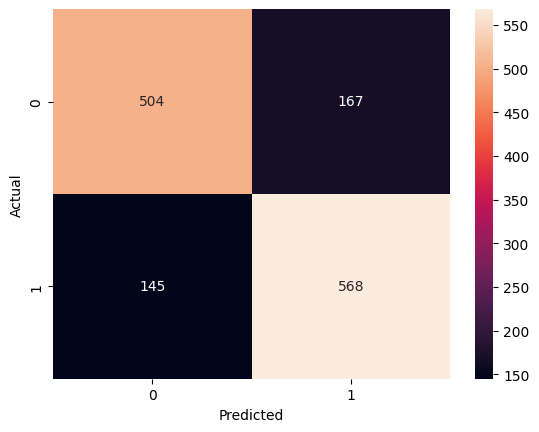

In [6]:
# Evaluate on test data
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")

# Classification report
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 5. Visualize Sentiment in a Network Graph

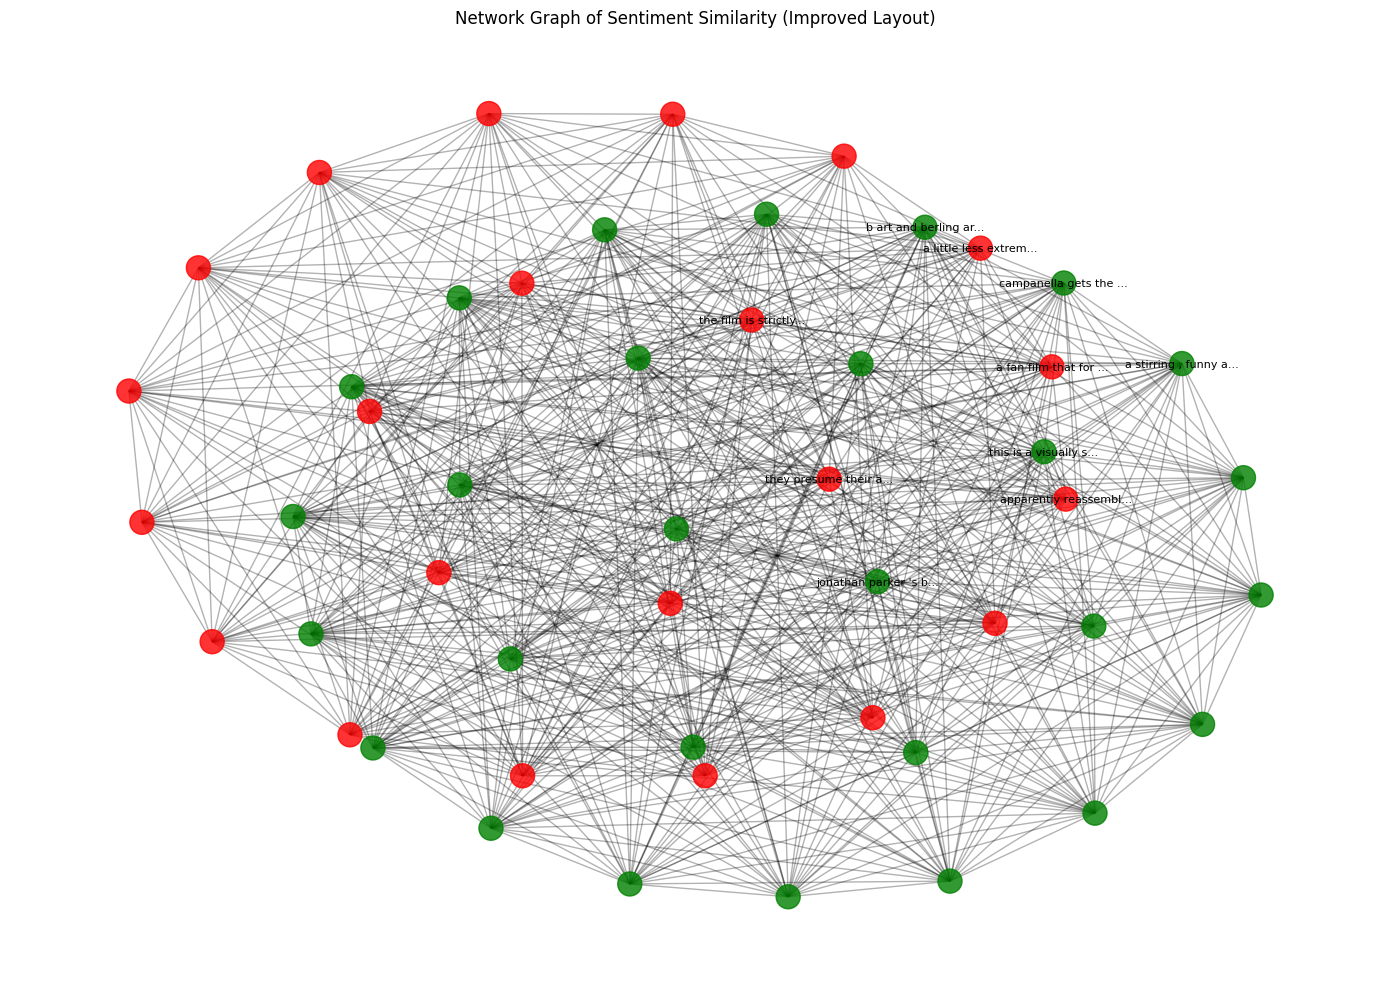

In [7]:
G = nx.Graph()
for i, row in df.head(50).iterrows():
    G.add_node(i, label=row["sentence"], sentiment=row["label"])
    for j in range(i):
        if df.loc[j, "label"] == row["label"]:
            G.add_edge(i, j)

plt.figure(figsize=(14, 10))
colors = ["red" if G.nodes[n]["sentiment"] == 0 else "green" for n in G.nodes]

# Use Kamada-Kawai layout for better separation
pos = nx.kamada_kawai_layout(G)

# Draw nodes and edges with improved clarity
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=300, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=1)
# Show only a few labels for clarity
labels = {n: G.nodes[n]["label"][:20] + "..." for n in list(G.nodes)[:10]}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title("Network Graph of Sentiment Similarity (Improved Layout)")
plt.axis("off")
plt.tight_layout()
plt.show()